In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/startup_valuation_dataset.csv")

STEP 1: DATASET OVERVIEW

In [3]:
df

,startup_id,startup_name,founded_year,country,region,industry,funding_round,funding_amount_usd,funding_date,lead_investor,co_investors,employee_count,estimated_revenue_usd,estimated_valuation_usd,exited,exit_type,tags
0,456bf4d2-b982-41e7-83fe-04bac2053405,Rice-Martinez,2008,Latvia,North America,Blockchain,Series A,764048000,2020-03-15,Sequoia,Y Combinator,106,2.898777e+08,5.187327e+09,False,NaN,"EdTech, Mobile"
1,ed442136-e5ec-43c5-afdf-a2dc08c5d4a2,Edwards-Page,2006,Guyana,North America,Fintech,Series A,379993000,2017-04-09,Tiger Global,"Accel, Tiger Global, Sequoia",735,4.567835e+07,1.234201e+09,False,NaN,"Cloud, IoT, SaaS, AI, Mobile"
2,a2cdddb6-9944-49c1-9391-6c98eb18f694,Thomas Ltd,2010,Uzbekistan,Oceania,SaaS,Series A,2513368000,2015-09-09,Sequoia,Index Ventures,346,1.489498e+08,2.452866e+10,True,Acquisition,"Marketplace, HealthTech"
3,eccc5d1e-54d8-4e60-ac80-7ff2cf98f3ba,Davis Inc,2013,Equatorial Guinea,North America,Blockchain,Series B,1029083000,2018-10-15,Accel,"Accel, Tiger Global",302,4.369478e+08,3.806283e+09,False,NaN,"EdTech, Cloud, B2B, AI"
4,81d6dfb6-63c7-4e0e-ad85-bd92d6a9302b,"Ryan, Dominguez and Klein",2012,Lithuania,Asia,Fintech,Series D,265731000,2020-01-12,Index Ventures,SoftBank,286,4.966752e+07,1.647014e+09,False,NaN,"B2C, Marketplace, EdTech, Cloud"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,d7a689c4-99ba-4409-90f8-dfacd530d590,"Powell, Barrera and Bridges",2011,Korea,MENA,Fintech,Pre-Seed,1603071000,2016-03-03,Y Combinator,"Y Combinator, Index Ventures",45,2.809650e+08,1.352763e+10,False,NaN,"HealthTech, EdTech, Cloud, B2C"
49996,09d20b48-8794-4bc7-99a0-2141f0c23877,"Glover, Davis and Lee",2023,Luxembourg,Oceania,Healthcare,Series A,63550000,2025-05-12,Y Combinator,"Andreessen Horowitz, Y Combinator, Sequoia",822,1.655495e+07,3.563540e+08,False,NaN,"IoT, SaaS, Marketplace, HealthTech"
49997,fd4ceaba-64dd-406c-937f-2ae8e4739063,Johnston-Dalton,2010,Haiti,Latin America,SaaS,Series C,470781000,2018-01-30,SoftBank,"Index Ventures, Accel",455,2.302360e+08,3.590469e+09,False,NaN,"Marketplace, Blockchain, SaaS, HealthTech"
49998,b2b9a989-c40a-43ad-8d53-dc01fc72d1f8,Duarte Ltd,2012,Cayman Islands,Asia,Logistics,Series C,938136000,2019-01-15,SoftBank,Tiger Global,890,4.350096e+08,5.713991e+09,True,NaN,"B2B, Blockchain, AI"


In [4]:
df.head()

,startup_id,startup_name,founded_year,country,region,industry,funding_round,funding_amount_usd,funding_date,lead_investor,co_investors,employee_count,estimated_revenue_usd,estimated_valuation_usd,exited,exit_type,tags
0,456bf4d2-b982-41e7-83fe-04bac2053405,Rice-Martinez,2008,Latvia,North America,Blockchain,Series A,764048000,2020-03-15,Sequoia,Y Combinator,106,2.898777e+08,5.187327e+09,False,NaN,"EdTech, Mobile"
1,ed442136-e5ec-43c5-afdf-a2dc08c5d4a2,Edwards-Page,2006,Guyana,North America,Fintech,Series A,379993000,2017-04-09,Tiger Global,"Accel, Tiger Global, Sequoia",735,4.567835e+07,1.234201e+09,False,NaN,"Cloud, IoT, SaaS, AI, Mobile"
2,a2cdddb6-9944-49c1-9391-6c98eb18f694,Thomas Ltd,2010,Uzbekistan,Oceania,SaaS,Series A,2513368000,2015-09-09,Sequoia,Index Ventures,346,1.489498e+08,2.452866e+10,True,Acquisition,"Marketplace, HealthTech"
3,eccc5d1e-54d8-4e60-ac80-7ff2cf98f3ba,Davis Inc,2013,Equatorial Guinea,North America,Blockchain,Series B,1029083000,2018-10-15,Accel,"Accel, Tiger Global",302,4.369478e+08,3.806283e+09,False,NaN,"EdTech, Cloud, B2B, AI"
4,81d6dfb6-63c7-4e0e-ad85-bd92d6a9302b,"Ryan, Dominguez and Klein",2012,Lithuania,Asia,Fintech,Series D,265731000,2020-01-12,Index Ventures,SoftBank,286,4.966752e+07,1.647014e+09,False,NaN,"B2C, Marketplace, EdTech, Cloud"


In [5]:
df.shape

(50000, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   startup_id               50000 non-null  object 
 1   startup_name             50000 non-null  object 
 2   founded_year             50000 non-null  int64  
 3   country                  50000 non-null  object 
 4   region                   50000 non-null  object 
 5   industry                 50000 non-null  object 
 6   funding_round            50000 non-null  object 
 7   funding_amount_usd       50000 non-null  int64  
 8   funding_date             50000 non-null  object 
 9   lead_investor            50000 non-null  object 
 10  co_investors             50000 non-null  object 
 11  employee_count           50000 non-null  int64  
 12  estimated_revenue_usd    50000 non-null  float64
 13  estimated_valuation_usd  50000 non-null  float64
 14  exited                

In [7]:
df.describe()

,founded_year,funding_amount_usd,employee_count,estimated_revenue_usd,estimated_valuation_usd
count,50000.000000,5.000000e+04,50000.000000,5.000000e+04,5.000000e+04
mean,2013.980260,8.119339e+08,502.425040,2.231884e+08,4.887720e+09
std,5.491855,1.273724e+09,289.125299,4.014473e+08,8.277873e+09
min,2005.000000,3.925000e+06,2.000000,6.220172e+05,1.279469e+07
25%,2009.000000,2.102280e+08,252.000000,4.554807e+07,1.092857e+09
50%,2014.000000,4.398320e+08,503.000000,1.068597e+08,2.442209e+09
75%,2019.000000,9.262392e+08,752.000000,2.455208e+08,5.465729e+09
max,2023.000000,6.103712e+10,1000.000000,2.304189e+10,3.220605e+11


In [8]:
cols=df.columns.to_list()
cols

['startup_id',
 'startup_name',
 'founded_year',
 'country',
 'region',
 'industry',
 'funding_round',
 'funding_amount_usd',
 'funding_date',
 'lead_investor',
 'co_investors',
 'employee_count',
 'estimated_revenue_usd',
 'estimated_valuation_usd',
 'exited',
 'exit_type',
 'tags']

STEP 2: DATA QUALITY ASSESSMENT

In [9]:
df.isnull().sum()

startup_id                     0
startup_name                   0
founded_year                   0
country                        0
region                         0
industry                       0
funding_round                  0
funding_amount_usd             0
funding_date                   0
lead_investor                  0
co_investors                   0
employee_count                 0
estimated_revenue_usd          0
estimated_valuation_usd        0
exited                         0
exit_type                  45100
tags                           0
dtype: int64

In [10]:
missing = (df.isnull().sum()/len(df))*100

missing.sort_values(ascending=False)

exit_type                  90.2
startup_id                  0.0
lead_investor               0.0
exited                      0.0
estimated_valuation_usd     0.0
estimated_revenue_usd       0.0
employee_count              0.0
co_investors                0.0
funding_date                0.0
startup_name                0.0
funding_amount_usd          0.0
funding_round               0.0
industry                    0.0
region                      0.0
country                     0.0
founded_year                0.0
tags                        0.0
dtype: float64

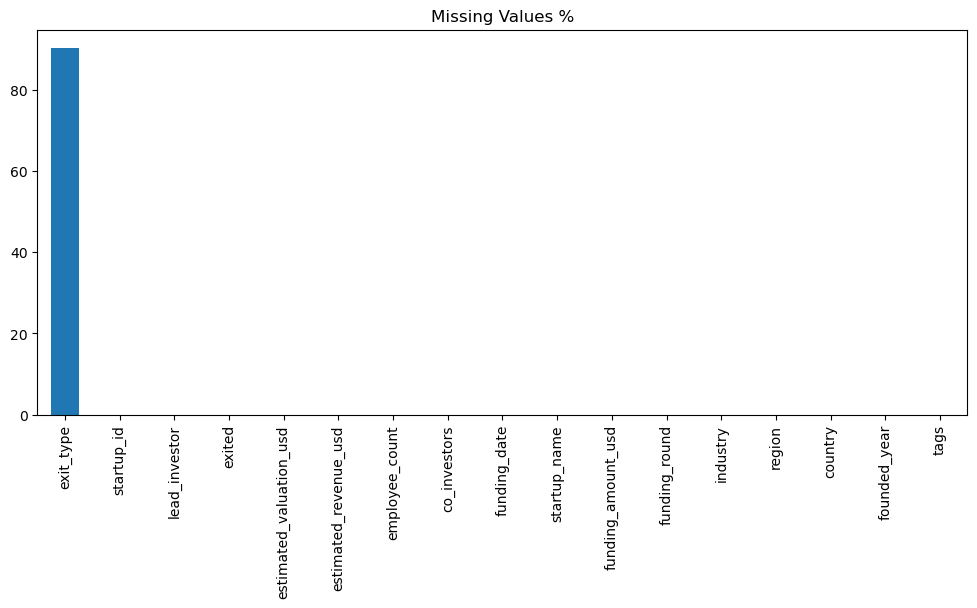

In [11]:
plt.figure(figsize=(12,5))

missing.sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Missing Values %")
plt.show()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
for col in df.columns:
    print(col,":",df[col].nunique())

startup_id : 50000
startup_name : 36866
founded_year : 19
country : 243
region : 6
industry : 7
funding_round : 7
funding_amount_usd : 48988
funding_date : 3653
lead_investor : 7
co_investors : 259
employee_count : 999
estimated_revenue_usd : 50000
estimated_valuation_usd : 50000
exited : 2
exit_type : 2
tags : 18644


In [14]:
df["unicorn"] = (
    df["estimated_valuation_usd"] >= 1_000_000_000
).astype(int)

In [15]:
df["unicorn"].value_counts()

unicorn
1    38675
0    11325
Name: count, dtype: int64

In [16]:
df["unicorn"].value_counts(normalize=True)*100

unicorn
1    77.35
0    22.65
Name: proportion, dtype: float64

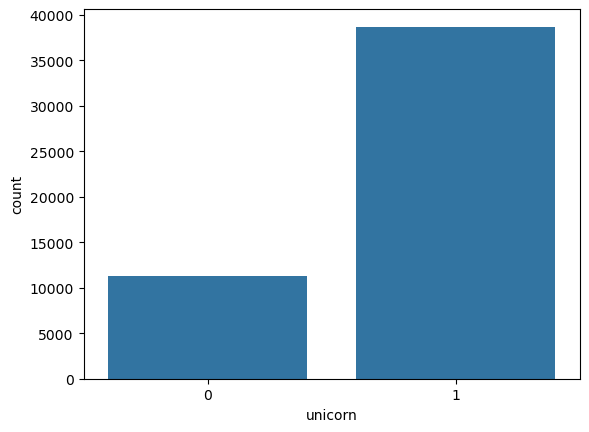

In [17]:
sns.countplot(
    x="unicorn",
    data=df
)

plt.show()

In [18]:
num_cols = [
    "funding_amount_usd",
    "employee_count",
    "estimated_revenue_usd",
    "estimated_valuation_usd"
]

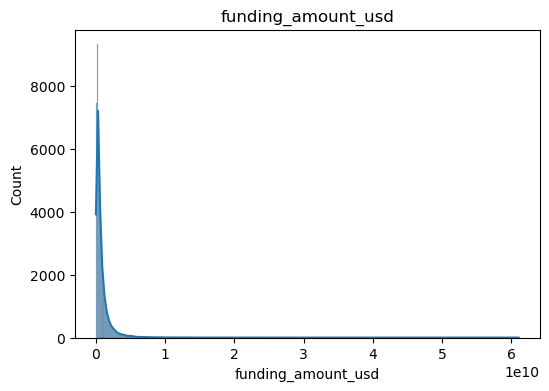

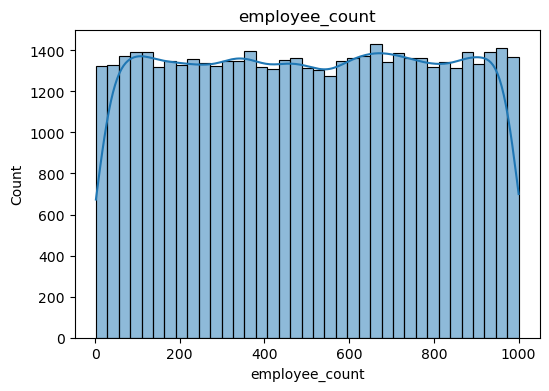

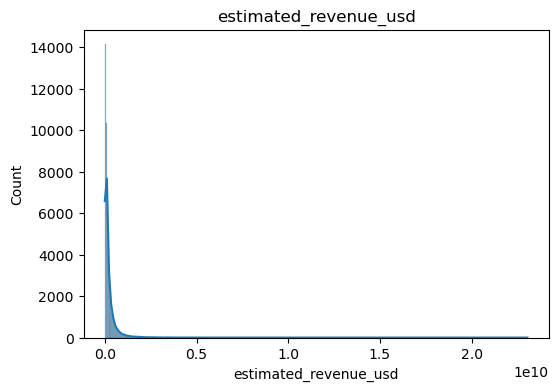

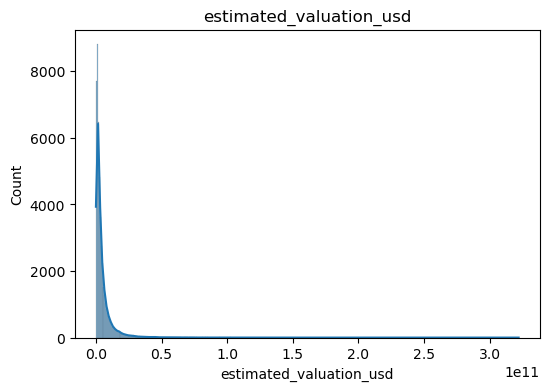

In [19]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

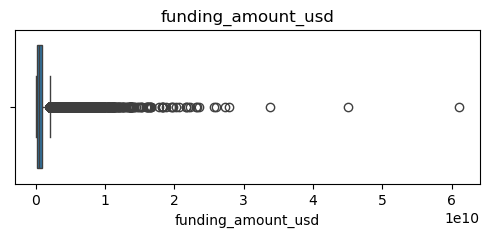

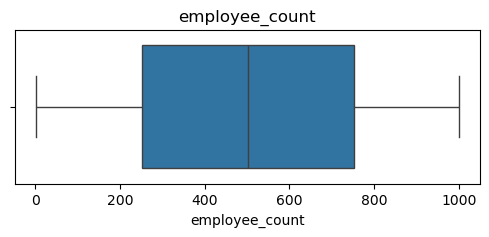

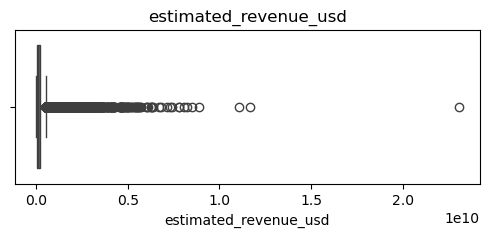

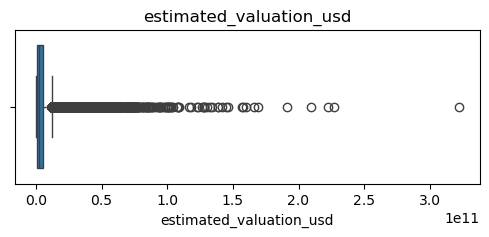

In [20]:
for col in num_cols:

    plt.figure(figsize=(6,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

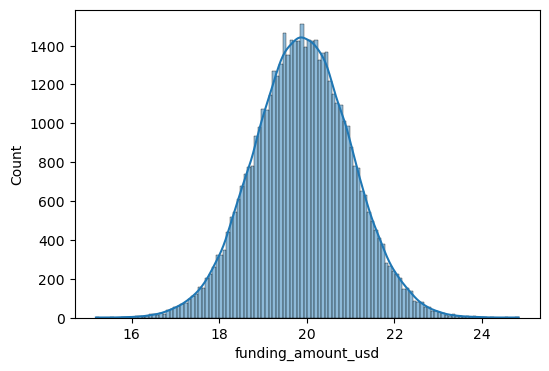

In [21]:
plt.figure(figsize=(6,4))

sns.histplot(
    np.log1p(df["funding_amount_usd"]),
    kde=True
)

plt.show()

In [22]:
cat_cols = [
    "industry",
    "country",
    "funding_round",
    "lead_investor"
]

In [23]:
for col in cat_cols:

    print(df[col].value_counts().head(10))

industry
Fintech       7259
AI/ML         7241
E-commerce    7155
SaaS          7140
Blockchain    7090
Logistics     7086
Healthcare    7029
Name: count, dtype: int64
country
Congo                         429
Korea                         378
United Kingdom                250
Slovakia (Slovak Republic)    240
Iraq                          239
Lesotho                       238
Norfolk Island                237
United Arab Emirates          235
British Virgin Islands        235
Bangladesh                    234
Name: count, dtype: int64
funding_round
Series B    11877
Series A    11837
Series C     8924
Seed         5803
Series D     5764
IPO          2943
Pre-Seed     2852
Name: count, dtype: int64
lead_investor
SoftBank               7287
Andreessen Horowitz    7200
Tiger Global           7170
Index Ventures         7123
Accel                  7103
Y Combinator           7093
Sequoia                7024
Name: count, dtype: int64


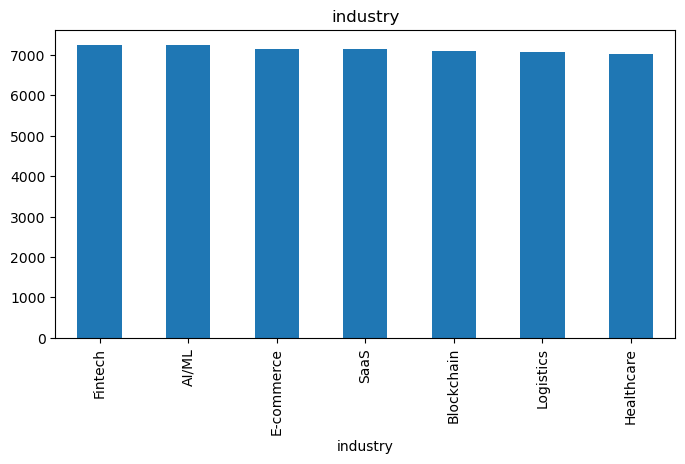

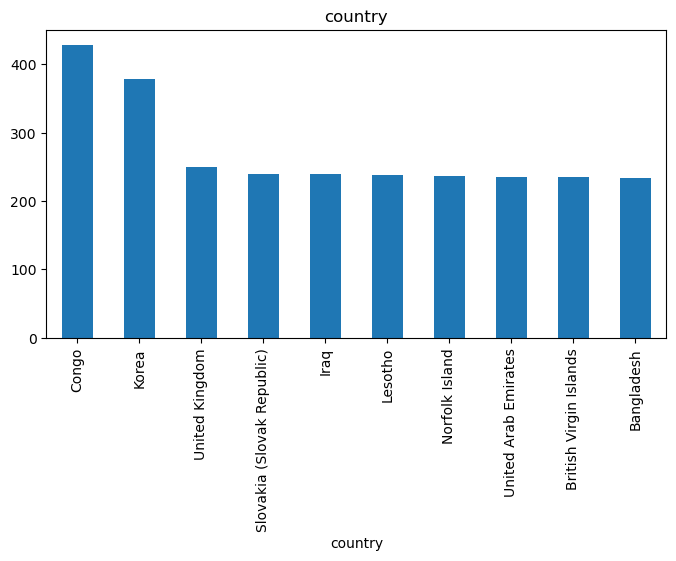

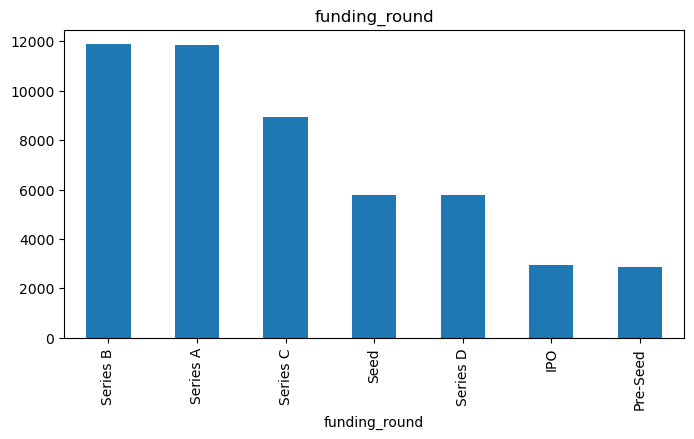

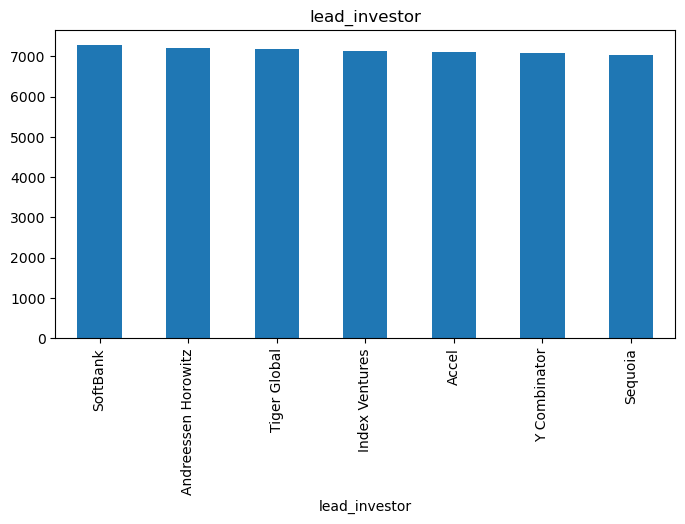

In [24]:
for col in cat_cols:

    plt.figure(figsize=(8,4))

    df[col].value_counts().head(10).plot(
        kind='bar'
    )

    plt.title(col)

    plt.show()

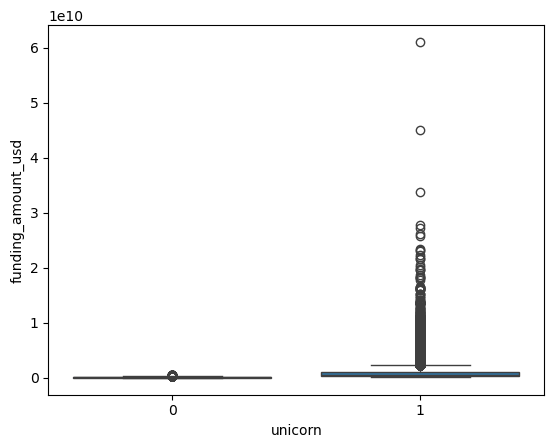

In [25]:
sns.boxplot(
    x="unicorn",
    y="funding_amount_usd",
    data=df
)

plt.show()

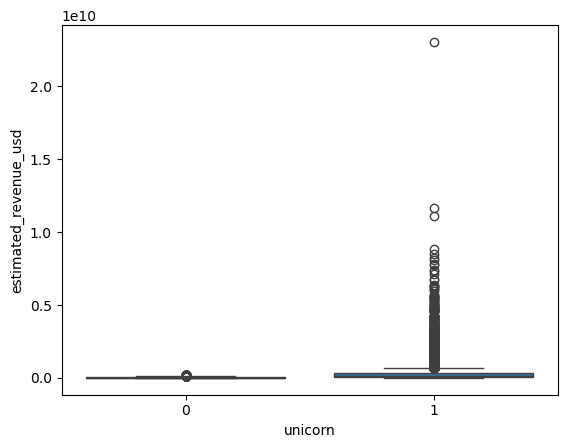

In [26]:
sns.boxplot(
    x="unicorn",
    y="estimated_revenue_usd",
    data=df
)

plt.show()

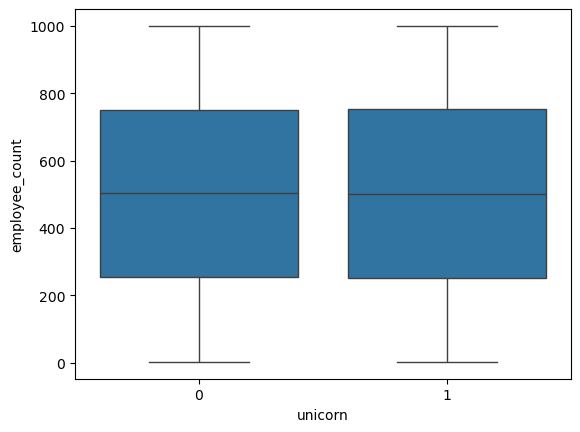

In [27]:
sns.boxplot(
    x="unicorn",
    y="employee_count",
    data=df
)

plt.show()

In [28]:
industry_unicorn = pd.crosstab(
    df["industry"],
    df["unicorn"]
)

industry_unicorn.head()

unicorn,0,1
industry,,
AI/ML,1637,5604
Blockchain,1608,5482
E-commerce,1596,5559
Fintech,1618,5641
Healthcare,1606,5423


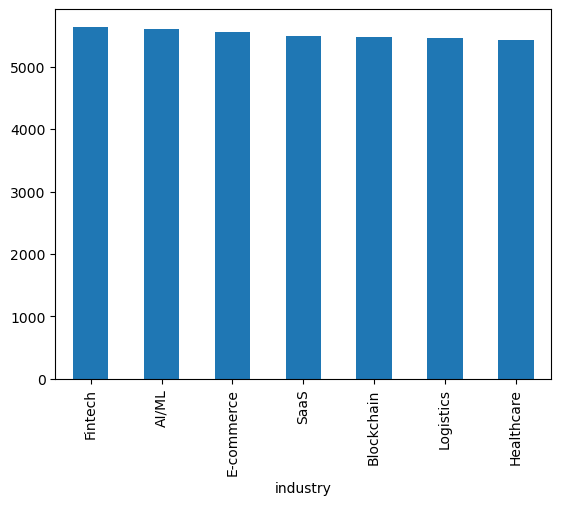

In [29]:
industry_unicorn[1]\
.sort_values(ascending=False)\
.head(15)\
.plot(kind="bar")

plt.show()

In [30]:
country_unicorn = pd.crosstab(
    df["country"],
    df["unicorn"]
)

In [31]:
round_unicorn = pd.crosstab(
    df["funding_round"],
    df["unicorn"]
)

round_unicorn

unicorn,0,1
funding_round,,
IPO,647,2296
Pre-Seed,636,2216
Seed,1328,4475
Series A,2715,9122
Series B,2649,9228
Series C,2006,6918
Series D,1344,4420


In [32]:
num_df = df.select_dtypes(
    include=np.number
)

corr = num_df.corr()

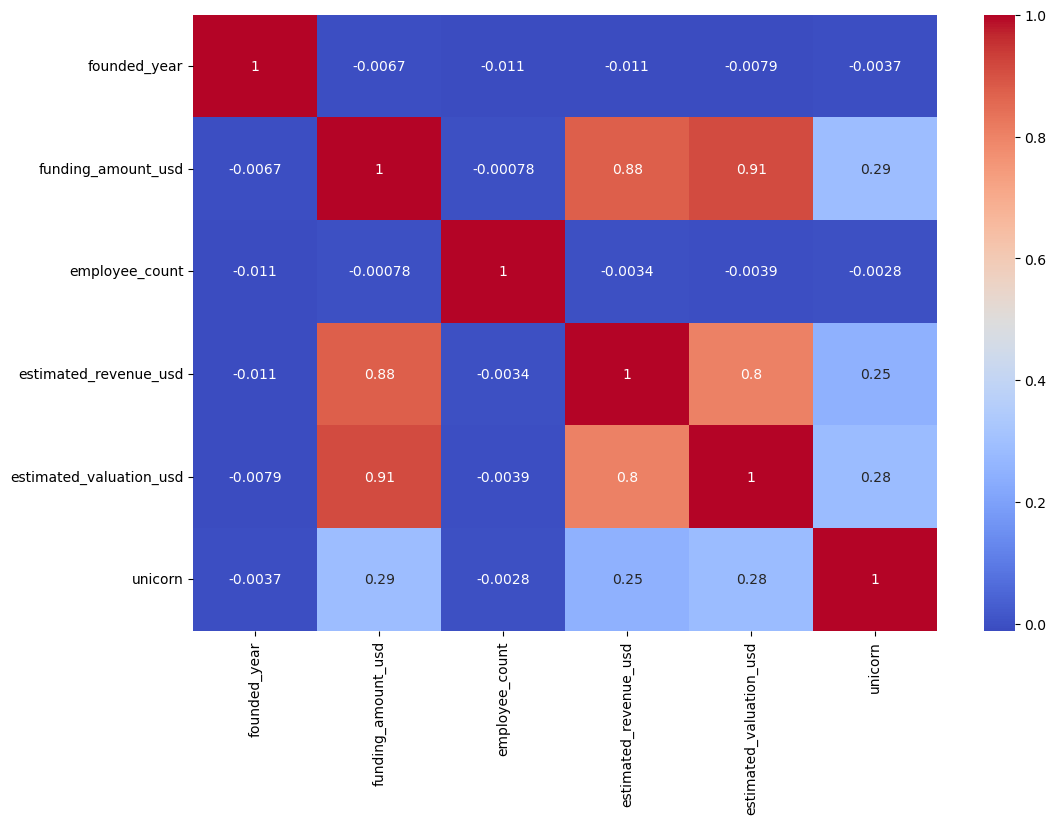

In [33]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

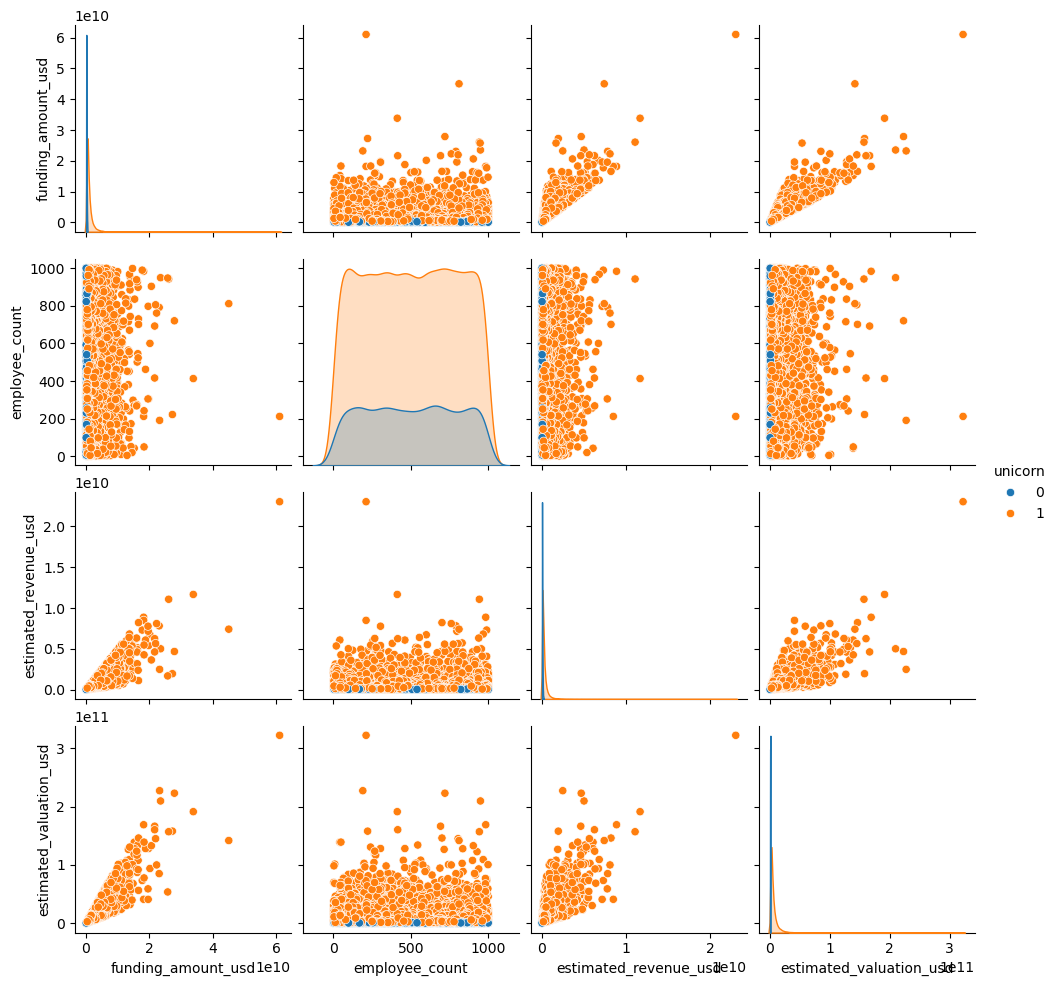

In [34]:
sns.pairplot(
    df[
        [
            "funding_amount_usd",
            "employee_count",
            "estimated_revenue_usd",
            "estimated_valuation_usd",
            "unicorn"
        ]
    ],
    hue="unicorn"
)

In [35]:
df["industry"]\
.value_counts()\
.head(10)

industry
Fintech       7259
AI/ML         7241
E-commerce    7155
SaaS          7140
Blockchain    7090
Logistics     7086
Healthcare    7029
Name: count, dtype: int64

In [36]:
df["lead_investor"]\
.value_counts()\
.head(10)

lead_investor
SoftBank               7287
Andreessen Horowitz    7200
Tiger Global           7170
Index Ventures         7123
Accel                  7103
Y Combinator           7093
Sequoia                7024
Name: count, dtype: int64

In [37]:
df.groupby("country")["unicorn"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

country
Congo                     350
Korea                     291
United Kingdom            198
Lesotho                   189
Norfolk Island            187
British Virgin Islands    187
Vietnam                   185
Bangladesh                185
United Arab Emirates      185
El Salvador               184
Name: unicorn, dtype: int64

In [38]:
df.groupby("industry")[
    "funding_amount_usd"
].mean()\
.sort_values(ascending=False)\
.head(10)

industry
E-commerce    8.322093e+08
AI/ML         8.162683e+08
Blockchain    8.156431e+08
Logistics     8.155294e+08
SaaS          8.040818e+08
Healthcare    8.006940e+08
Fintech       7.991001e+08
Name: funding_amount_usd, dtype: float64

In [39]:
df.groupby("industry")[
    "estimated_valuation_usd"
].mean()\
.sort_values(ascending=False)\
.head(10)

industry
E-commerce    5.029973e+09
Blockchain    4.924263e+09
AI/ML         4.902011e+09
Logistics     4.885703e+09
Healthcare    4.870913e+09
SaaS          4.827862e+09
Fintech       4.774680e+09
Name: estimated_valuation_usd, dtype: float64

In [40]:
raw_df = pd.read_csv(
    "../data/startup_valuation_dataset.csv"
)

In [41]:
import joblib
import pandas as pd

raw_df = pd.read_csv(
    "../data/startup_valuation_dataset.csv"
)

country_freq = (
    raw_df["country"]
    .value_counts(normalize=True)
    .to_dict()
)

joblib.dump(
    country_freq,
    "../models/country_freq.pkl"
)

print("Saved Successfully")

Saved Successfully


In [42]:
import joblib
import pandas as pd

raw_df = pd.read_csv(
    "../data/startup_valuation_dataset.csv"
)

In [43]:
joblib.dump(
    sorted(raw_df["region"].dropna().unique()),
    "../models/region_categories.pkl"
)

['../models/region_categories.pkl']

In [44]:
joblib.dump(
    sorted(raw_df["industry"].dropna().unique()),
    "../models/industry_categories.pkl"
)

['../models/industry_categories.pkl']

In [45]:
joblib.dump(
    sorted(raw_df["funding_round"].dropna().unique()),
    "../models/funding_round_categories.pkl"
)

['../models/funding_round_categories.pkl']

In [46]:
joblib.dump(
    sorted(raw_df["lead_investor"].dropna().unique()),
    "../models/lead_investor_categories.pkl"
)

['../models/lead_investor_categories.pkl']